In [1]:
import pandas as pd
import numpy as np

In [2]:
health = pd.read_excel("/kaggle/input/food-nutrition-data/2025-food-environment-atlas-data.xlsx" , sheet_name="HEALTH", header = 1)

In [3]:
health.head()

,FIPS,State,County,PCT_DIABETES_ADULTS15,PCT_DIABETES_ADULTS19,PCT_OBESE_ADULTS17,PCT_OBESE_ADULTS22,PCT_HSPA21,RECFAC16,RECFAC20,PCH_RECFAC_16_20,RECFACPTH16,RECFACPTH20,PCH_RECFACPTH_16_20
0,1001,AL,Autauga,9.1,9.6,36.3,38.3,18.0,6,9,50.000000,0.108495,0.160299,47.747802
1,1003,AL,Baldwin,8.6,7.9,36.3,38.3,18.0,21,22,4.761905,0.101065,0.095950,-5.061506
2,1005,AL,Barbour,12.7,11.3,36.3,38.3,18.0,-9999,-9999,-9999.000000,-9999.000000,-9999.000000,-9999.000000
3,1007,AL,Bibb,9.9,10.2,36.3,38.3,18.0,1,-9999,-9999.000000,0.044267,-9999.000000,-9999.000000
4,1009,AL,Blount,9.9,9.5,36.3,38.3,18.0,4,4,0.000000,0.069581,0.069110,-0.677278


In [4]:
health.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3144 entries, 0 to 3143
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FIPS                   3144 non-null   int64  
 1   State                  3144 non-null   object 
 2   County                 3144 non-null   object 
 3   PCT_DIABETES_ADULTS15  3144 non-null   float64
 4   PCT_DIABETES_ADULTS19  3144 non-null   float64
 5   PCT_OBESE_ADULTS17     3144 non-null   float64
 6   PCT_OBESE_ADULTS22     3144 non-null   float64
 7   PCT_HSPA21             3144 non-null   float64
 8   RECFAC16               3144 non-null   int64  
 9   RECFAC20               3144 non-null   int64  
 10  PCH_RECFAC_16_20       3144 non-null   float64
 11  RECFACPTH16            3144 non-null   float64
 12  RECFACPTH20            3144 non-null   float64
 13  PCH_RECFACPTH_16_20    3144 non-null   float64
dtypes: float64(9), int64(3), object(2)
memory usage: 344.0+ 

In [5]:
health.isna().sum()

FIPS                     0
State                    0
County                   0
PCT_DIABETES_ADULTS15    0
PCT_DIABETES_ADULTS19    0
PCT_OBESE_ADULTS17       0
PCT_OBESE_ADULTS22       0
PCT_HSPA21               0
RECFAC16                 0
RECFAC20                 0
PCH_RECFAC_16_20         0
RECFACPTH16              0
RECFACPTH20              0
PCH_RECFACPTH_16_20      0
dtype: int64

In [6]:
health = health.replace(["N/A",-9999,-8888],np.nan)

In [7]:
health.isna().sum()


FIPS                        0
State                       0
County                      0
PCT_DIABETES_ADULTS15       2
PCT_DIABETES_ADULTS19      24
PCT_OBESE_ADULTS17          2
PCT_OBESE_ADULTS22          1
PCT_HSPA21                275
RECFAC16                 1010
RECFAC20                 1850
PCH_RECFAC_16_20         1854
RECFACPTH16              1010
RECFACPTH20              1850
PCH_RECFACPTH_16_20      1854
dtype: int64

In [8]:
null_percent = (health.isna().sum() / len(health) * 100).round(2)
print(null_percent.sort_values(ascending=False))


PCH_RECFAC_16_20         58.97
PCH_RECFACPTH_16_20      58.97
RECFAC20                 58.84
RECFACPTH20              58.84
RECFAC16                 32.12
RECFACPTH16              32.12
PCT_HSPA21                8.75
PCT_DIABETES_ADULTS19     0.76
PCT_DIABETES_ADULTS15     0.06
PCT_OBESE_ADULTS17        0.06
PCT_OBESE_ADULTS22        0.03
FIPS                      0.00
State                     0.00
County                    0.00
dtype: float64


In [9]:
num_cols = ['PCT_DIABETES_ADULTS15', 'PCT_DIABETES_ADULTS19',
            'PCT_OBESE_ADULTS17', 'PCT_OBESE_ADULTS22',
            'PCT_HSPA21', 'RECFAC16', 'RECFAC20', 
            'PCH_RECFAC_16_20', 'RECFACPTH16', 
            'RECFACPTH20', 'PCH_RECFACPTH_16_20']

for col in num_cols:
    health[col] = health[col].replace([-9999, -8888, 'N/A'], np.nan) 
    health[col] = health[col].fillna(health[col].median())  


In [10]:
health

,FIPS,State,County,PCT_DIABETES_ADULTS15,PCT_DIABETES_ADULTS19,PCT_OBESE_ADULTS17,PCT_OBESE_ADULTS22,PCT_HSPA21,RECFAC16,RECFAC20,PCH_RECFAC_16_20,RECFACPTH16,RECFACPTH20,PCH_RECFACPTH_16_20
0,1001,AL,Autauga,9.1,9.6,36.3,38.3,18.0,6.0,9.0,50.000000,0.108495,0.160299,47.747802
1,1003,AL,Baldwin,8.6,7.9,36.3,38.3,18.0,21.0,22.0,4.761905,0.101065,0.095950,-5.061506
2,1005,AL,Barbour,12.7,11.3,36.3,38.3,18.0,4.0,9.0,13.333333,0.091228,0.109302,10.106812
3,1007,AL,Bibb,9.9,10.2,36.3,38.3,18.0,1.0,9.0,13.333333,0.044267,0.109302,10.106812
4,1009,AL,Blount,9.9,9.5,36.3,38.3,18.0,4.0,4.0,0.000000,0.069581,0.069110,-0.677278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3139,56037,WY,Sweetwater,8.3,7.6,28.8,34.3,17.0,6.0,4.0,-33.333333,0.135382,0.093736,-30.761837
3140,56039,WY,Teton,4.1,4.2,28.8,34.3,17.0,13.0,14.0,7.692308,0.559020,0.595821,6.583161
3141,56041,WY,Uinta,9.3,7.3,28.8,34.3,17.0,2.0,9.0,13.333333,0.096567,0.109302,10.106812
3142,56043,WY,Washakie,8.6,8.8,28.8,34.3,17.0,1.0,9.0,13.333333,0.122249,0.109302,10.106812


In [11]:
cat_cols = ['State', 'County']
for col in cat_cols:
    health[col] = health[col].fillna(health[col].mode()[0])

In [12]:
health.describe()

,FIPS,PCT_DIABETES_ADULTS15,PCT_DIABETES_ADULTS19,PCT_OBESE_ADULTS17,PCT_OBESE_ADULTS22,PCT_HSPA21,RECFAC16,RECFAC20,PCH_RECFAC_16_20,RECFACPTH16,RECFACPTH20,PCH_RECFACPTH_16_20
count,3144.000000,3144.00000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000,3144.000000
mean,30365.634542,8.29173,8.739504,31.863868,35.223601,16.826908,12.089059,17.486323,17.778420,0.099581,0.113986,14.885575
std,15174.497197,1.58393,1.613658,3.328616,3.265520,3.576130,36.650446,44.172410,36.146400,0.058794,0.038958,35.522836
min,1001.000000,3.70000,4.100000,22.600000,24.300000,8.100000,1.000000,3.000000,-63.157895,0.009132,0.025226,-63.726385
25%,18174.500000,7.17500,7.500000,30.100000,33.400000,14.400000,2.000000,9.000000,13.333333,0.074739,0.109302,10.106812
50%,29174.000000,8.00000,8.400000,32.400000,35.500000,17.000000,4.000000,9.000000,13.333333,0.091228,0.109302,10.106812
75%,45079.500000,9.20000,9.600000,33.800000,37.700000,19.400000,6.000000,9.000000,13.333333,0.108024,0.109302,10.106812
max,56045.000000,17.40000,17.600000,38.100000,41.000000,24.800000,939.000000,1202.000000,500.000000,1.054852,0.595821,495.386503


In [13]:
health.isnull().sum()

FIPS                     0
State                    0
County                   0
PCT_DIABETES_ADULTS15    0
PCT_DIABETES_ADULTS19    0
PCT_OBESE_ADULTS17       0
PCT_OBESE_ADULTS22       0
PCT_HSPA21               0
RECFAC16                 0
RECFAC20                 0
PCH_RECFAC_16_20         0
RECFACPTH16              0
RECFACPTH20              0
PCH_RECFACPTH_16_20      0
dtype: int64

In [14]:
health[num_cols].skew().sort_values(ascending=False)

RECFAC20                 11.571252
RECFAC16                 10.594409
PCH_RECFACPTH_16_20       5.307401
PCH_RECFAC_16_20          5.227242
RECFACPTH16               4.929204
RECFACPTH20               3.747074
PCT_DIABETES_ADULTS19     1.027004
PCT_DIABETES_ADULTS15     0.943152
PCT_HSPA21                0.217111
PCT_OBESE_ADULTS17       -0.632436
PCT_OBESE_ADULTS22       -0.884728
dtype: float64

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
health[num_cols] = scaler.fit_transform(health[num_cols])

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


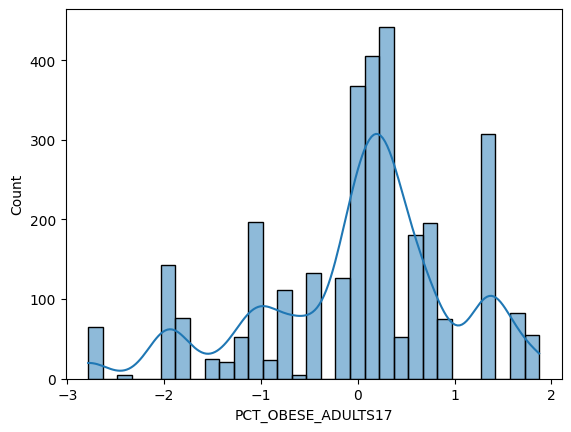

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(health['PCT_OBESE_ADULTS17'].dropna(), kde=True)
plt.show()

In [17]:
health.describe()

,FIPS,PCT_DIABETES_ADULTS15,PCT_DIABETES_ADULTS19,PCT_OBESE_ADULTS17,PCT_OBESE_ADULTS22,PCT_HSPA21,RECFAC16,RECFAC20,PCH_RECFAC_16_20,RECFACPTH16,RECFACPTH20,PCH_RECFACPTH_16_20
count,3144.000000,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03
mean,30365.634542,6.779988e-16,-4.610392e-16,-1.220398e-16,-2.983195e-16,2.711995e-16,-9.039984e-18,-2.485996e-17,-1.129998e-17,6.779988e-17,8.135986e-17,9.039984e-18
std,15174.497197,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00
min,1001.000000,-2.899409e+00,-2.875604e+00,-2.783541e+00,-3.345665e+00,-2.440710e+00,-3.026108e-01,-3.280017e-01,-2.239481e+00,-1.538663e+00,-2.278724e+00,-2.213350e+00
25%,18174.500000,-7.051498e-01,-7.682551e-01,-5.299945e-01,-5.585298e-01,-6.787489e-01,-2.753217e-01,-1.921487e-01,-1.229941e-01,-4.225954e-01,-1.202467e-01,-1.345479e-01
50%,29174.000000,-1.842106e-01,-2.104274e-01,1.610932e-01,8.465525e-02,4.840963e-02,-2.207434e-01,-1.921487e-01,-1.229941e-01,-1.421106e-01,-1.202467e-01,-1.345479e-01
75%,45079.500000,5.735192e-01,5.333429e-01,5.817553e-01,7.584682e-01,7.196329e-01,-1.661652e-01,-1.921487e-01,-1.229941e-01,1.436149e-01,-1.202467e-01,-1.345479e-01
max,56045.000000,5.751340e+00,5.491811e+00,1.873789e+00,1.769188e+00,2.229885e+00,2.529460e+01,2.681996e+01,1.334291e+01,1.625039e+01,1.237001e+01,1.352869e+01


In [18]:
health_analysis = health.drop(columns=['FIPS', 'State', 'County'])
health_analysis.describe()

,PCT_DIABETES_ADULTS15,PCT_DIABETES_ADULTS19,PCT_OBESE_ADULTS17,PCT_OBESE_ADULTS22,PCT_HSPA21,RECFAC16,RECFAC20,PCH_RECFAC_16_20,RECFACPTH16,RECFACPTH20,PCH_RECFACPTH_16_20
count,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03,3.144000e+03
mean,6.779988e-16,-4.610392e-16,-1.220398e-16,-2.983195e-16,2.711995e-16,-9.039984e-18,-2.485996e-17,-1.129998e-17,6.779988e-17,8.135986e-17,9.039984e-18
std,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00,1.000159e+00
min,-2.899409e+00,-2.875604e+00,-2.783541e+00,-3.345665e+00,-2.440710e+00,-3.026108e-01,-3.280017e-01,-2.239481e+00,-1.538663e+00,-2.278724e+00,-2.213350e+00
25%,-7.051498e-01,-7.682551e-01,-5.299945e-01,-5.585298e-01,-6.787489e-01,-2.753217e-01,-1.921487e-01,-1.229941e-01,-4.225954e-01,-1.202467e-01,-1.345479e-01
50%,-1.842106e-01,-2.104274e-01,1.610932e-01,8.465525e-02,4.840963e-02,-2.207434e-01,-1.921487e-01,-1.229941e-01,-1.421106e-01,-1.202467e-01,-1.345479e-01
75%,5.735192e-01,5.333429e-01,5.817553e-01,7.584682e-01,7.196329e-01,-1.661652e-01,-1.921487e-01,-1.229941e-01,1.436149e-01,-1.202467e-01,-1.345479e-01
max,5.751340e+00,5.491811e+00,1.873789e+00,1.769188e+00,2.229885e+00,2.529460e+01,2.681996e+01,1.334291e+01,1.625039e+01,1.237001e+01,1.352869e+01


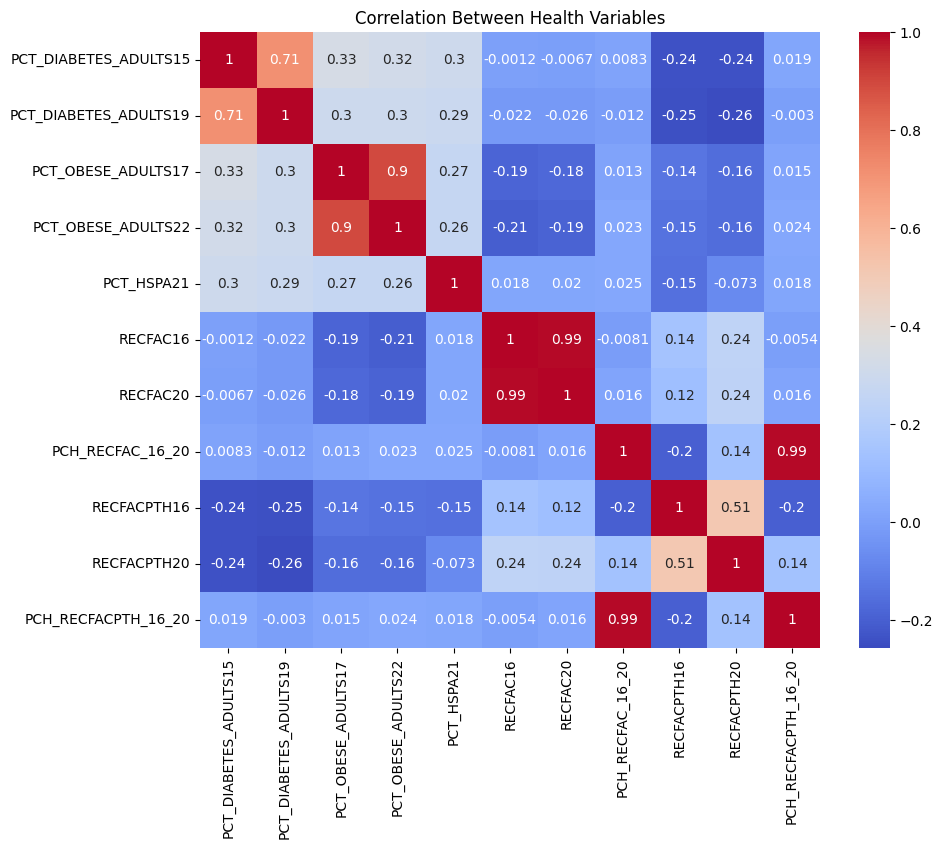

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(health_analysis.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Between Health Variables')
plt.show()

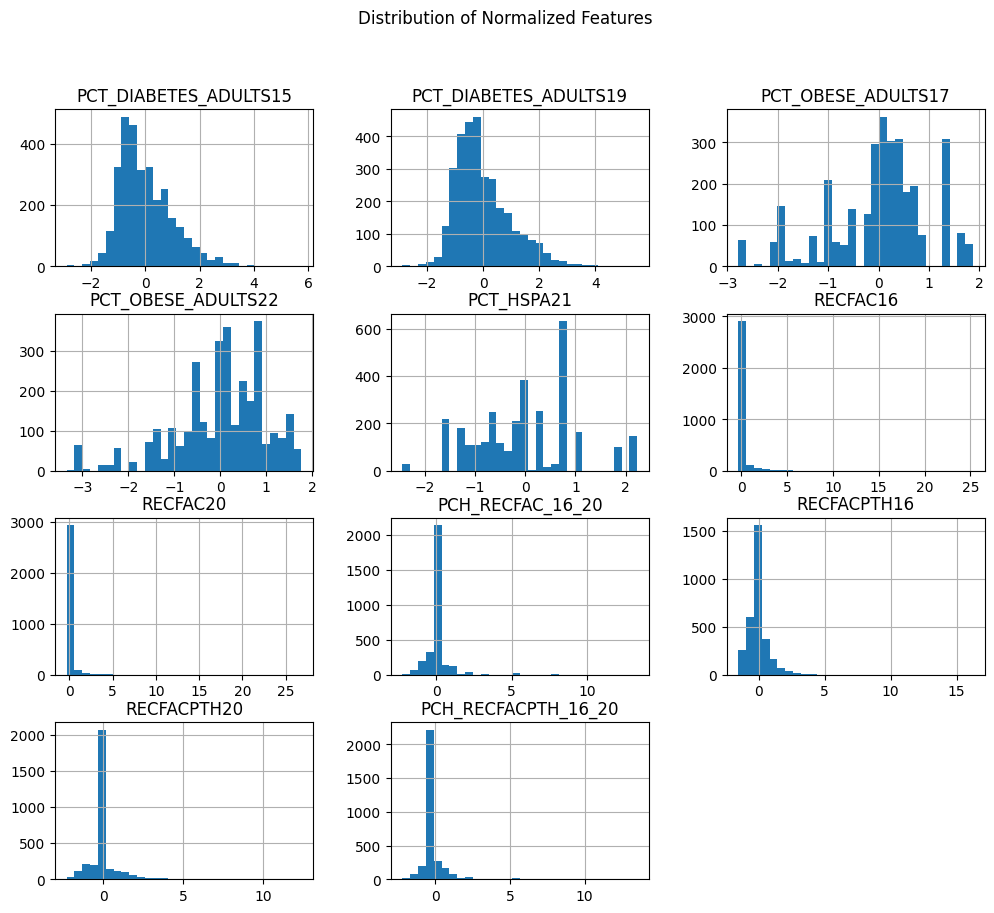

In [20]:
health_analysis.hist(figsize=(12,10), bins=30)
plt.suptitle("Distribution of Normalized Features")
plt.show()

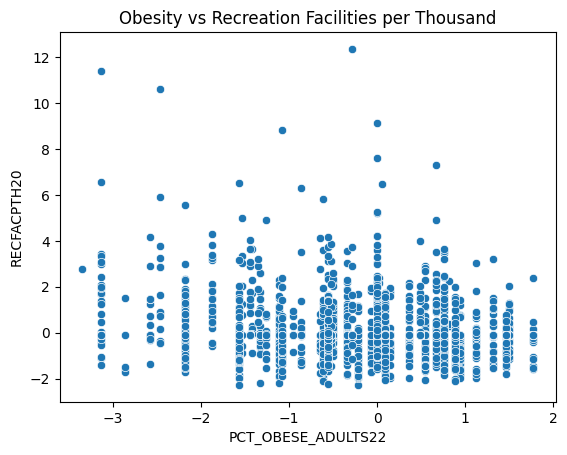

In [21]:
sns.scatterplot(
    x='PCT_OBESE_ADULTS22',
    y='RECFACPTH20',
    data=health,
)
plt.title('Obesity vs Recreation Facilities per Thousand')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

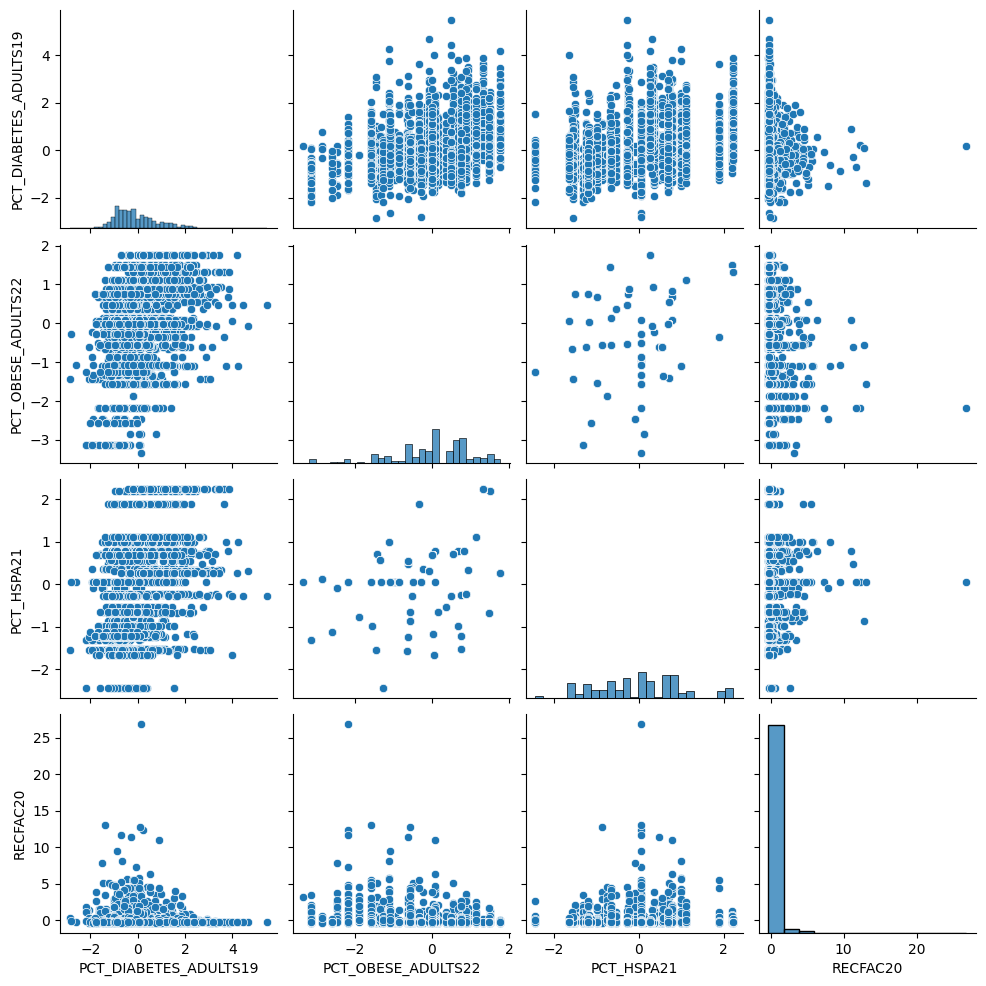

In [22]:
import seaborn as sns

sns.pairplot(health, vars=["PCT_DIABETES_ADULTS19", "PCT_OBESE_ADULTS22", "PCT_HSPA21", "RECFAC20"])
plt.show()

In [23]:
region_avg = (
    health.groupby("State")[["PCT_DIABETES_ADULTS19", "PCT_OBESE_ADULTS22", "PCT_HSPA21"]]
    .mean()
    .sort_values("PCT_OBESE_ADULTS22", ascending=False)
)

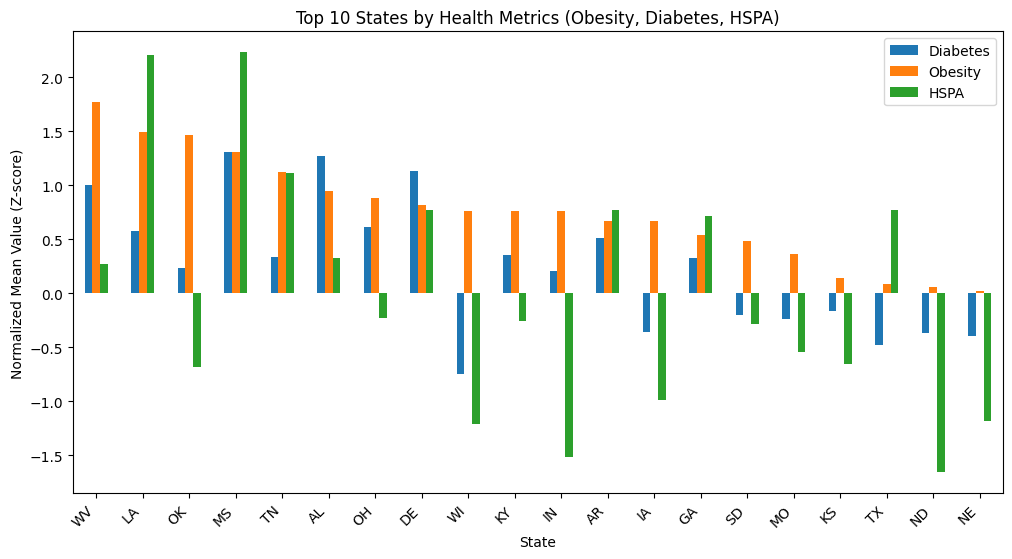

In [24]:
region_avg.head(20).plot(kind="bar", figsize=(12,6))

plt.title("Top 10 States by Health Metrics (Obesity, Diabetes, HSPA)")
plt.ylabel("Normalized Mean Value (Z-score)")
plt.xlabel("State")
plt.legend(["Diabetes", "Obesity", "HSPA"])
plt.xticks(rotation=45, ha="right")  # Rotate labels so they are readable
plt.show()